In [2]:
import pandas as pd
import numpy as np

from folktables import ACSDataSource, ACSIncome, ACSTravelTime

In [14]:
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

state_train = "CA"
train_year = 2014

_yearly_data = {}


data_source = ACSDataSource(
    survey_year=str(train_year), horizon="1-Year", survey="person"
)
acs_data = data_source.get_data(states=[state_train], download=True)

_yearly_data[train_year] = ACSTravelTime.df_to_numpy(acs_data)

for y in years:
    try:
        data_source = ACSDataSource(
            survey_year=str(y), horizon="1-Year", survey="person"
        )
        acs_data = data_source.get_data(states=["NY"], download=True)

        _yearly_data[y] = ACSTravelTime.df_to_numpy(acs_data)
    except:
        pass


data/2020/1-Year/csv_pny.zip may be corrupted. Please try deleting it and rerunning this command.

Exception:  File is not a zip file


In [15]:
X, y, z = _yearly_data[train_year]

In [16]:
_yearly_data.keys()

dict_keys([2014, 2015, 2016, 2017, 2018])

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

###### Your favorite learning algorithm here #####
model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X, y)


for y2 in _yearly_data.keys():
    X_test, y_test, group_test = _yearly_data[y2]

    y_pred = model.predict(X_test)

    white_tpr = np.mean(y_pred[(y_test == 1) & (group_test == 1)])
    black_tpr = np.mean(y_pred[(y_test == 1) & (group_test == 2)])

    print("%i - %f" % (y2, white_tpr - black_tpr))

2014 - 0.073593
2015 - 0.175443
2016 - 0.168636
2017 - 0.164271
2018 - 0.163330


In [12]:
X.shape

(18922, 16)

In [22]:
cols_X = ["X_%i" % i for i in range(len(X[0]))]

aif_df = pd.DataFrame()

In [23]:
for i in range(len(X[0])):
    aif_df["X_%i" % i] = X[:, i]

aif_df["race"] = z
aif_df["<20min"] = y

In [24]:
aif_df

,X_0,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,X_11,X_12,X_13,X_14,X_15,race,<20min
0,36.0,16.0,5.0,1.0,2.0,0.0,1.0,12.0,1.0,8513.0,6.0,1.0,9610.0,2.0,8500.0,14.0,1,True
1,47.0,20.0,3.0,2.0,2.0,0.0,1.0,0.0,1.0,7301.0,6.0,1.0,5700.0,1.0,7300.0,345.0,1,False
2,20.0,19.0,5.0,1.0,2.0,0.0,1.0,2.0,1.0,7301.0,6.0,1.0,4840.0,1.0,7300.0,345.0,1,False
3,31.0,19.0,1.0,2.0,2.0,0.0,1.0,0.0,1.0,1903.0,6.0,1.0,5120.0,1.0,1900.0,452.0,1,False
4,31.0,19.0,1.0,1.0,2.0,0.0,1.0,1.0,1.0,1903.0,6.0,1.0,5550.0,1.0,1900.0,452.0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160260,63.0,19.0,3.0,2.0,2.0,0.0,1.0,0.0,8.0,6508.0,6.0,4.0,4720.0,1.0,6500.0,501.0,8,False
160261,38.0,20.0,5.0,1.0,2.0,0.0,1.0,2.0,8.0,6508.0,6.0,1.0,3320.0,1.0,6500.0,501.0,8,False
160262,40.0,21.0,1.0,2.0,2.0,0.0,1.0,0.0,1.0,9904.0,6.0,1.0,6440.0,1.0,9900.0,397.0,1,False
160263,40.0,20.0,1.0,1.0,2.0,0.0,1.0,1.0,1.0,9904.0,6.0,1.0,3740.0,1.0,9900.0,397.0,1,False


In [25]:
aif_df.columns

Index(['X_0', 'X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8', 'X_9',
       'X_10', 'X_11', 'X_12', 'X_13', 'X_14', 'X_15', 'race', '<20min'],
      dtype='object')

In [27]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.metrics import ClassificationMetric
from aif360.algorithms.preprocessing.reweighing import Reweighing

_label_names = ["<20min"]
_protected_attribute_names = ["race"]
_favorable_label = 1
_unfavorable_label = 0


original_data = BinaryLabelDataset(
    df=aif_df,
    label_names=_label_names,
    protected_attribute_names=_protected_attribute_names,
    favorable_label=_favorable_label,
    unfavorable_label=_unfavorable_label,
)

privileged_groups = [{"race": 1}]
unprivileged_groups = [{"race": 2}]

In [28]:
RW = Reweighing(
    unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups
)
RW.fit(original_data)
transformed_data = RW.transform(original_data)

In [29]:
w = transformed_data.instance_weights

###### Your favorite learning algorithm here #####
fair_model = make_pipeline(StandardScaler(), RandomForestClassifier())
fair_model.fit(X, y, randomforestclassifier__sample_weight=w)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier', RandomForestClassifier())])

In [35]:
def test_on_state_data(state_name, years, _model):
    # Evaluate model on 2015-2018 data
    accuracies = []
    eq_opps = []
    tnrs = []

    for year in [2015, 2016, 2017, 2018]:
        data_source = ACSDataSource(survey_year=year, horizon="1-Year", survey="person")
        acs_data = data_source.get_data(states=[state_name], download=True)
        features, labels, group_test = ACSTravelTime.df_to_numpy(acs_data)

        y_pred = _model.predict(features)

        accuracies.append(_model.score(features, labels))

        white_tpr = np.mean(y_pred[(labels == 1) & (group_test == 1)])
        black_tpr = np.mean(y_pred[(labels == 1) & (group_test == 2)])

        white_fnr = 1 - np.mean(y_pred[(labels == 0) & (group_test == 1)])
        black_fnr = 1 - np.mean(y_pred[(labels == 0) & (group_test == 2)])

        eq_opps.append(white_tpr - black_tpr)
        tnrs.append(white_fnr - black_fnr)

    return accuracies, eq_opps, tnrs

In [38]:
test_on_state_data("CA", [2015, 2016, 2017, 2018], model)

([0.563526634706641,
  0.5675015125466494,
  0.5659349717959891,
  0.5686113107797899],
 [0.055485097589185406,
  0.04627285128542219,
  0.04739031017654821,
  0.04999952932206514],
 [0.010602155334309527,
  -0.01352747993772574,
  0.004597237900321072,
  0.004358564185043767])

In [34]:
test_on_state_data("CA", [2015, 2016, 2017, 2018], fair_model)

([0.6708928527973134,
  0.6701869567561415,
  0.668605815090029,
  0.6644329538340251],
 [-0.055927140858063606,
  -0.08172910956104518,
  -0.04762700398346198,
  -0.05645763105455004],
 [0.05177913305537685,
  0.0668127144167534,
  0.09364201721234378,
  0.0746207602232909])

In [36]:
test_on_state_data("NY", [2015, 2016, 2017, 2018], model)

([0.4741490153617108,
  0.4746200011217679,
  0.474411074767899,
  0.473969298245614],
 [0.17544346781439274,
  0.16863597582197623,
  0.1642710656271512,
  0.16332951400151613],
 [-0.04832138124277874,
  -0.02211182066849182,
  -0.052292695764829644,
  -0.043940173867096366])

In [37]:
test_on_state_data("NY", [2015, 2016, 2017, 2018], fair_model)

([0.708725271254878, 0.7077458073924505, 0.70634684640037, 0.7027631578947369],
 [-0.29959082836560647,
  -0.28727534991153153,
  -0.27147660945152635,
  -0.2742096586613897],
 [0.1174485911565758,
  0.10785445367742763,
  0.08433840104677481,
  0.09426557341035235])

In [18]:
abbreviations = [
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#States.
    "AK",
    "AL",
    "AR",
    "AZ",
    "CA",
    "CO",
    "CT",
    "DE",
    "FL",
    "GA",
    "HI",
    "IA",
    "ID",
    "IL",
    "IN",
    "KS",
    "KY",
    "LA",
    "MA",
    "MD",
    "ME",
    "MI",
    "MN",
    "MO",
    "MS",
    "MT",
    "NC",
    "ND",
    "NE",
    "NH",
    "NJ",
    "NM",
    "NV",
    "NY",
    "OH",
    "OK",
    "OR",
    "PA",
    "RI",
    "SC",
    "SD",
    "TN",
    "TX",
    "UT",
    "VA",
    "VT",
    "WA",
    "WI",
    "WV",
    "WY",
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#Federal_district.
    "DC",
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#Inhabited_territories.
    "AS",
    "GU",
    "MP",
    "PR",
    "VI",
]

In [19]:
smaller_acc = 1
bigger_acc = 0
best_s = ""
worst_s = ""

for s in abbreviations:
    try:
        ret = test_on_state_data(s, [2015], model)

        if ret[0][0] > bigger_acc:
            bigger_acc = ret[0][0]
            best_s = s

        if ret[0][0] < smaller_acc:
            smaller_acc = ret[0][0]
            worst_s = s
    except:
        pass

In [20]:
print(best_s, worst_s)

AK AK


In [71]:
import pandas as pd

from sklearn.cluster import DBSCAN, KMeans

filenameFinal = "Clusteringv3.xlsx"

finalDF = pd.read_excel(filenameFinal)


N_CLUSTERS = 5
db = KMeans(n_clusters=N_CLUSTERS, random_state=0, n_init="auto").fit(
    finalDF.to_numpy()
)

db = DBSCAN(eps=0.7, min_samples=1, metric="precomputed").fit(finalDF.to_numpy())
# db = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(finalDF.to_numpy())

print(db.labels_)

[-1  0 -1 -1 -1  0  0 -1  0  0 -1 -1  0  0 -1  0  0  0  0  0 -1 -1  0 -1
  0 -1  0  0 -1 -1 -1  0  0  0  0 -1 -1 -1  0]


In [76]:
_X = finalDF.to_numpy()
for i in range(len(_X)):
    if (_X[i] < 0.5).any():
        print(i)

1
6
9
15
16
17
18
24
26
31
32
33


(array([   2.,    2.,    6.,    6.,   14.,   70.,   34.,   56.,   74.,
        1257.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

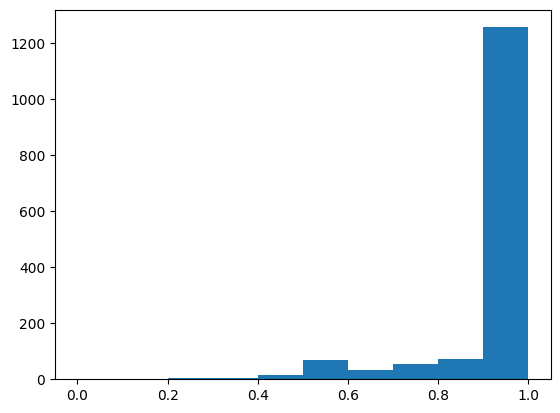

In [69]:
import matplotlib.pyplot as plt

plt.hist(finalDF.to_numpy().ravel())

In [39]:
f = "acs_travel_time.csv"


state_train = "CA"
state_test = "NY"
train_year = 2014

_yearly_data = {}

_states = []
_states.append("CA")


data_source = ACSDataSource(
    survey_year=str(train_year), horizon="1-Year", survey="person"
)
acs_data = data_source.get_data(states=[state_train], download=True)

acs_data["_state"] = state_train
acs_data["_year"] = 2014

for y in years:
    try:
        data_source = ACSDataSource(
            survey_year=str(y), horizon="1-Year", survey="person"
        )
        acs_data2 = data_source.get_data(states=[state_test], download=True)
        acs_data2["_state"] = state_test
        acs_data2["_year"] = y

        acs_data = pd.concat((acs_data, acs_data2))

    except:
        pass

In [42]:
acs_data

,RT,SERIALNO,SPORDER,PUMA,ST,ADJINC,PWGTP,AGEP,CIT,CITWP,...,pwgtp71,pwgtp72,pwgtp73,pwgtp74,pwgtp75,pwgtp76,pwgtp77,pwgtp78,pwgtp79,pwgtp80
0,P,18,1,8513,6,1008425,139,54,1,NaN,...,142,155,39,37,215,196,39,121,225,146
1,P,18,2,8513,6,1008425,216,36,1,NaN,...,217,244,57,67,350,358,61,191,299,241
2,P,52,1,7301,6,1008425,260,47,1,NaN,...,484,498,59,72,431,328,69,399,413,284
3,P,52,2,7301,6,1008425,312,20,1,NaN,...,476,503,86,86,503,317,102,453,499,319
4,P,52,3,7301,6,1008425,252,0,1,NaN,...,510,437,66,65,413,283,76,374,381,247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372548,P,1501115,3,9904,6,1008425,179,14,1,NaN,...,192,311,213,213,203,57,181,189,288,198
372549,P,1501115,4,9904,6,1008425,180,11,1,NaN,...,191,311,213,211,203,57,181,190,290,197
372550,P,1501115,5,9904,6,1008425,272,19,1,NaN,...,347,541,274,364,296,124,238,205,439,306
372551,P,1501118,1,6514,6,1008425,37,79,1,NaN,...,12,58,36,39,11,67,31,36,78,10


In [ ]:


_yearly_data[train_year] = 

for y in years:
    
    try:
        data_source = ACSDataSource(survey_year=str(y), horizon='1-Year', survey='person')
        acs_data = data_source.get_data(states=["NY"], download=True)

        _yearly_data[y] = ACSTravelTime.df_to_numpy(acs_data)
    except:
        pass    

